# Conditional VAE Coordinates Data Generator

Variational Autoencoders (VAEs) map input features to continuous latent spaces, modeling probability distributions ($q(z|x)$) to generate new samples. Standard VAEs generate random samples, whereas **Conditional VAEs (CVAE)** feed category labels alongside coordinates to both the encoder and decoder. This enables targeted category data generation. This notebook implements a CVAE in PyTorch to generate class-specific 2D coordinates.



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic class-specific 2D coordinates (600 samples, 3 classes)
np.random.seed(225)
n_samples = 600

# Classes form distinct geometry coordinates shapes:
# Class 0: Line, Class 1: Circle ring, Class 2: Curved arch
X_list, y_list = [], []

# Class 0 (horizontal line)
X_0 = np.column_stack((np.random.uniform(-1.5, 1.5, 200), np.random.normal(0, 0.05, 200)))
X_list.append(X_0)
y_list.append(np.zeros(200))

# Class 1 (circle ring)
theta = np.random.uniform(0, 2*np.pi, 200)
X_1 = np.column_stack((np.cos(theta) * 0.8, np.sin(theta) * 0.8)) + np.random.normal(0, 0.04, (200, 2))
X_list.append(X_1)
y_list.append(np.ones(200))

# Class 2 (parabolic arch)
x_arch = np.random.uniform(-1.0, 1.0, 200)
y_arch = x_arch**2 - 0.5 + np.random.normal(0, 0.05, 200)
X_list.append(np.column_stack((x_arch, y_arch)))
y_list.append(np.full(200, 2))

X = np.vstack(X_list)
y = np.concatenate(y_list)

X_tensor = torch.FloatTensor(X) # [600, 2]
y_tensor = torch.LongTensor(y)  # [600]

print("Input Coordinates shape:", X_tensor.shape)
print("Condition Class shape:  ", y_tensor.shape)



Input Coordinates shape: torch.Size([600, 2])
Condition Class shape:   torch.Size([600])


## Conditional VAE Network Architecture

We implement the CVAE model in PyTorch, concatenating 1D one-hot label embeddings to inputs in both the encoder and decoder.



In [2]:
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim=2, latent_dim=2, num_classes=3):
        super(ConditionalVAE, self).__init__()
        
        # One-hot embedding dimension mapping
        self.label_embed = nn.Embedding(num_classes, num_classes)
        
        # Encoder Network: input + conditional label
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.mu_head = nn.Linear(16, latent_dim)
        self.logvar_head = nn.Linear(16, latent_dim)
        
        # Decoder Network: latent + conditional label
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
        
    def forward(self, x, c):
        c_embed = self.label_embed(c)
        
        # Encode
        enc_input = torch.cat([x, c_embed], dim=1)
        h = self.encoder(enc_input)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        
        # Latent sampling
        z = self.reparameterize(mu, logvar)
        
        # Decode
        dec_input = torch.cat([z, c_embed], dim=1)
        recon_x = self.decoder(dec_input)
        
        return recon_x, mu, logvar

# Initialize CVAE
cvae = ConditionalVAE()
optimizer = optim.Adam(cvae.parameters(), lr=0.01)



## CVAE Loss Minimization (ELBO) Training

We train the generator for 150 epochs. The loss combines MSE reconstruction error and KL divergence.



In [3]:
epochs = 150
losses = []

for epoch in range(1, epochs + 1):
    cvae.train()
    recon_x, mu, logvar = cvae(X_tensor, y_tensor)
    
    # 1. Reconstruction Loss (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, X_tensor, reduction='mean')
    
    # 2. KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Joint ELBO loss (scaled)
    loss = recon_loss + 0.1 * kl_loss
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 30 == 0:
         print(f"Epoch {epoch:3d}/{epochs} | Joint ELBO Loss: {loss.item():.4f} (Recon: {recon_loss.item():.4f}, KL: {kl_loss.item():.4f})")



Epoch  30/150 | Joint ELBO Loss: 0.1638 (Recon: 0.1065, KL: 0.5728)
Epoch  60/150 | Joint ELBO Loss: 0.1198 (Recon: 0.0469, KL: 0.7286)
Epoch  90/150 | Joint ELBO Loss: 0.1116 (Recon: 0.0409, KL: 0.7078)
Epoch 120/150 | Joint ELBO Loss: 0.1073 (Recon: 0.0370, KL: 0.7025)
Epoch 150/150 | Joint ELBO Loss: 0.1082 (Recon: 0.0359, KL: 0.7228)


## Target Generated Coordinates Plot

We evaluate targeted generator capabilities. By sampling from standard normal latent space and feeding specific class index labels (0, 1, or 2) into the decoder, we generate class-specific shapes.



<cell>:32: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



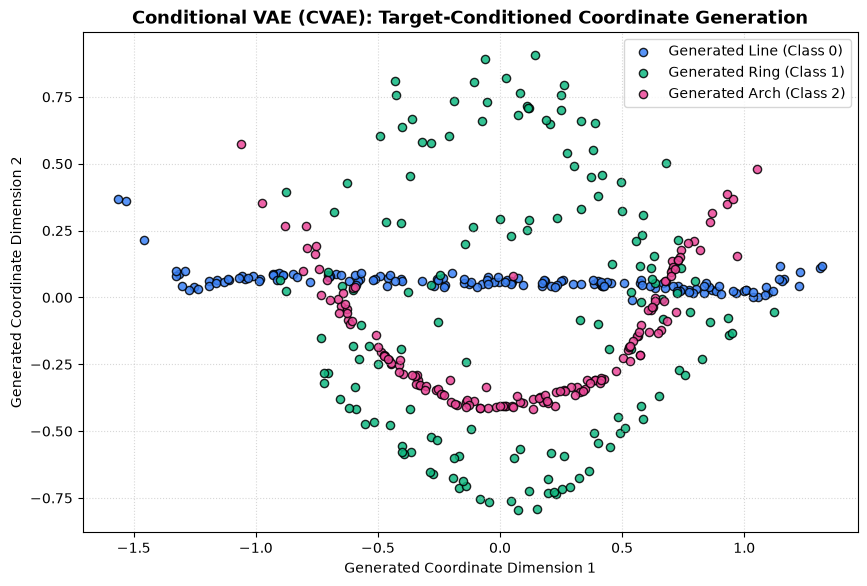

In [4]:
cvae.eval()
plt.figure(figsize=(10, 6.5))

colors = ['#3B82F6', '#10B981', '#EC4899']
labels_dict = {0: 'Generated Line (Class 0)', 1: 'Generated Ring (Class 1)', 2: 'Generated Arch (Class 2)'}

with torch.no_grad():
    for label in [0, 1, 2]:
        # Sample 150 random points from standard Gaussian latent space
        z = torch.randn(150, 2)
        c = torch.full((150,), label, dtype=torch.long)
        c_embed = cvae.label_embed(c)
        
        dec_input = torch.cat([z, c_embed], dim=1)
        generated_coords = cvae.decoder(dec_input).numpy()
        
        plt.scatter(
            generated_coords[:, 0], 
            generated_coords[:, 1], 
            c=colors[label], 
            label=labels_dict[label],
            edgecolors='k', 
            s=35, 
            alpha=0.85
        )

plt.title('Conditional VAE (CVAE): Target-Conditioned Coordinate Generation', fontsize=13, fontweight='bold')
plt.xlabel('Generated Coordinate Dimension 1')
plt.ylabel('Generated Coordinate Dimension 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
